<a href="https://colab.research.google.com/github/leejuheon06/Practice_ML_1/blob/main/06_%EC%9D%B4%EC%A7%84_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

[런타임] -> [세션 다시 시작] 후 아래 셀 실행

In [72]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [73]:
# 파이토치 관련 라이브러리

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchviz import make_dot   # 구조도 그리기

In [74]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

6.5 시그모이드 함수

In [75]:
np.arange(-4, 4.1, 0.25)
x_np = np.arange(-4, 4.1, 0.25)
torch.tensor(x_np).float()

tensor([-4.0000, -3.7500, -3.5000, -3.2500, -3.0000, -2.7500, -2.5000, -2.2500,
        -2.0000, -1.7500, -1.5000, -1.2500, -1.0000, -0.7500, -0.5000, -0.2500,
         0.0000,  0.2500,  0.5000,  0.7500,  1.0000,  1.2500,  1.5000,  1.7500,
         2.0000,  2.2500,  2.5000,  2.7500,  3.0000,  3.2500,  3.5000,  3.7500,
         4.0000])

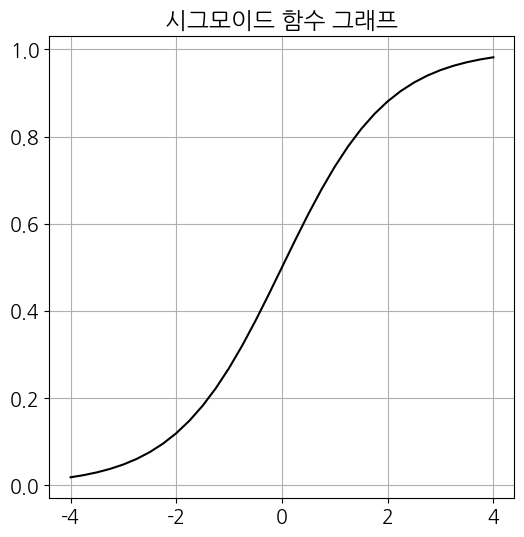

In [76]:
# 넘파이 배열로 x_np 정의
x_np = np.arange(-4, 4.1, 0.25)

# 텐서 변환
x = torch.tensor(x_np).float()

# y 계산
y = torch.sigmoid(x)
# 1 / (1 + exp(-x))

# 그래프 출력
plt.title('시그모이드 함수 그래프')
plt.plot(x.detach(), y.detach(), c='k')
plt.show()

6.7 데이터 불러오기

In [77]:
# 학습용 데이터 준비

# 라이브러리
from sklearn.datasets import load_iris

# 데이터 불러오기
iris = load_iris()

# 입력 데이터와 정답 데이터
x_org, y_org = iris.data, iris.target

# 원본 데이터의 크기를 확인 (총 150개의 데이터, 4개의 특징)
print('--- 1. 데이터 불러오기 결과 ---')
print('원본 데이터', x_org.shape, y_org.shape)

--- 1. 데이터 불러오기 결과 ---
원본 데이터 (150, 4) (150,)


In [78]:
# 이진 분류를 위해, 두 종류의 꽃 데이터(100개)와 두 개의 특징(꽃받침 길이/너비)만 사용
# 클래스는 0 또는 1

x_data = iris.data[:100,:2]
y_data = iris.target[:100]

# 추출한 데이터의 크기를 확인 (총 100개의 데이터, 2개의 특징)
print('--- 2. 데이터 추출 결과 ---')
print('대상 데이터', x_data.shape, y_data.shape)

--- 2. 데이터 추출 결과 ---
대상 데이터 (100, 2) (100,)


In [79]:
# 훈련 데이터와 검증 데이터로 분할
# 데이터 훈련용 70개, 검증용 30개
# train_test_split 함수는 데이터를 무작위로 섞어주므로 편향을 방지.
# random_state=123으로 설정하여 실행할 때마다 동일한 결과
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x_data, y_data, train_size=0.7, test_size=0.3, random_state=123
)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(70, 2) (30, 2) (70,) (30,)


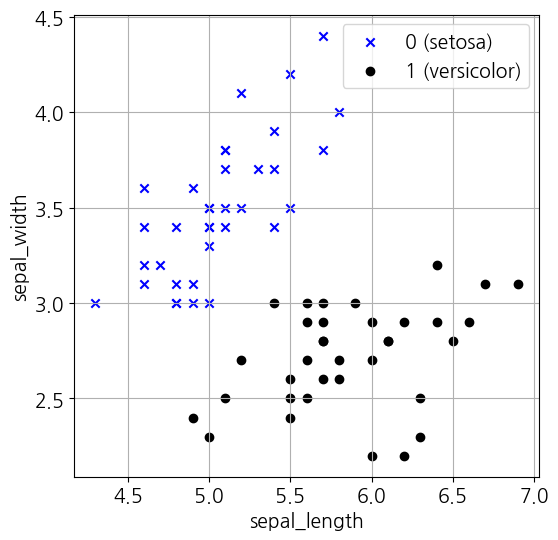

In [80]:
# 산포도 출력
x_t0 = x_train[y_train == 0]
x_t1 = x_train[y_train == 1]
plt.scatter(x_t0[:,0], x_t0[:,1], marker='x', c='b', label='0 (setosa)')
plt.scatter(x_t1[:,0], x_t1[:,1], marker='o', c='k', label='1 (versicolor)')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.legend()
plt.show()

6.8 모델 정의

In [81]:
x_train[1]

array([5.5, 2.6])

In [82]:
# 입력 차원수 (현재 2)
n_input = x_train.shape[1]

# 출력 차원수
n_output = 1

# 결과 확인
print(f'n_input : {n_input}, n_output : {n_output}')

n_input : 2, n_output : 1


In [83]:
# 모델 정의
class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.l1 = nn.Linear(n_input, n_output)
        self.sigmoid = nn.Sigmoid()

        # 초기값(가중치, 편향) 1로 초기화
        # (일반적인 경우에는 무작위 값으로 초기화)
        self.l1.weight.data.fill_(1.0)
        self.l1.bias.data.fill_(1.0)

    def forward(self, x):
        x1 = self.l1(x)
        x2 = self.sigmoid(x1)
        return x2

In [84]:
net = Net(n_input, n_output)

In [85]:
# 모델의 개요 표시 1
print(net)

Net(
  (l1): Linear(in_features=2, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [86]:
# 모델의 개요 표시 2
summary(net, (2,))
# (2,) : 입력데이터의 shape(형태)
# >> 데이터의 차원 : 1차원, 크기가 2인 벡터 입력으로 넣겠다는 의미 [x1, x2]

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [1]                       --
├─Linear: 1-1                            [1]                       3
├─Sigmoid: 1-2                           [1]                       --
Total params: 3
Trainable params: 3
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [87]:
# 모델 안의 파라미터 확인
# l1.weight와 l1.bias가 존재함을 알 수 있음

for parameter in net.named_parameters():
    print(parameter)

('l1.weight', Parameter containing:
tensor([[1., 1.]], requires_grad=True))
('l1.bias', Parameter containing:
tensor([1.], requires_grad=True))


In [88]:
# 손실 함수 : 교차 엔트로피 함수 (이진 분류)
criterion = nn.BCELoss()

# 학습률
lr = 0.01

# 최적화 함수 : 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

6.9 경사 하강법

In [89]:
torch.tensor(x_train).float()[:10]

tensor([[5.1000, 3.7000],
        [5.5000, 2.6000],
        [5.5000, 4.2000],
        [5.6000, 2.5000],
        [5.4000, 3.0000],
        [6.3000, 2.3000],
        [5.7000, 3.0000],
        [6.2000, 2.9000],
        [6.0000, 2.2000],
        [4.8000, 3.0000]])

In [90]:
# 훈련용 입력, 정답 데이터 텐서화
inputs = torch.tensor(x_train).float()
labels = torch.tensor(y_train).float()

# 정답 데이터 (N,1) 변환
labels1 = labels.view(-1,1)

# 검증용 입력, 정답 데이터 텐서화
inputs_test = torch.tensor(x_test).float()
labels_test = torch.tensor(y_test).float()

# 검증용 데이터 (N,1) 변환
labels_test1 = labels_test.view(-1,1)

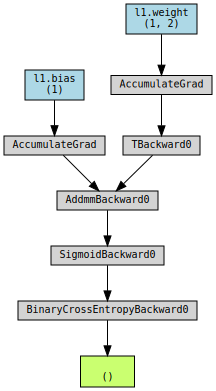

In [91]:
# 예측 계산
outputs = net(inputs)

# 손실 계산
loss = criterion(outputs, labels1)

# 손실 계산 그래프 출력
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

In [92]:
# 반복 계산
# 초기화 처리

# 학습률
lr = 0.01

# 초기화
net = Net(n_input, n_output)

# 손실 함수 : 교차 엔트로피 함수
criterion = nn.BCELoss()

# 최적화 함수 : 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 10000

# 기록 리스트 초기화
history = np.zeros((0,5))

In [93]:
# 반복 계산 메인 루프
for epoch in range(num_epochs):
    # 훈련
    optimizer.zero_grad()      # 경삿값 초기화
    outputs = net(inputs)      # 예측 계산
    loss = criterion(outputs, labels1) # 손실 계산
    loss.backward()            # 경사 계산
    optimizer.step()           # 파라미터 수정

    train_loss = loss.item()   # 손실 저장 (스칼라 값 취득)
    # 확률값을 0.5 기준으로 0 또는 1로 변환
    predicted = torch.where(outputs < 0.5, 0, 1)
    # 정확도 계산
    train_acc = (predicted == labels1).sum() / len(y_train)

    # 예측
    # 여기서는 경사 계산과 파라미터 수정이 필요 없습니다.
    outputs_test = net(inputs_test) # 예측 계산
    loss_test = criterion(outputs_test, labels_test1) # 손실 계산
    val_loss = loss_test.item() # 손실 저장
    predicted_test = torch.where(outputs_test < 0.5, 0, 1) # 예측 라벨(1 또는 0) 계산
    val_acc = (predicted_test == labels_test1).sum() / len(y_test) # 정확도 계산

    # 1000번에 한 번씩 결과 출력
    if (epoch % 1000 == 0):
        print(f'Epoch [{epoch+1}/{num_epochs}], loss: {train_loss:.5f}, acc: {train_acc:.5f}, val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
        # 기록
        item = np.array([epoch, train_loss, train_acc, val_loss, val_acc])
        history = np.vstack((history, item))

Epoch [1/10000], loss: 4.77289, acc: 0.50000, val_loss: 4.49384, val_acc: 0.50000
Epoch [1001/10000], loss: 0.36160, acc: 1.00000, val_loss: 0.40759, val_acc: 0.96667
Epoch [2001/10000], loss: 0.23677, acc: 1.00000, val_loss: 0.29188, val_acc: 0.96667
Epoch [3001/10000], loss: 0.18060, acc: 1.00000, val_loss: 0.24044, val_acc: 0.96667
Epoch [4001/10000], loss: 0.14842, acc: 1.00000, val_loss: 0.21159, val_acc: 0.96667
Epoch [5001/10000], loss: 0.12737, acc: 1.00000, val_loss: 0.19317, val_acc: 0.96667
Epoch [6001/10000], loss: 0.11243, acc: 1.00000, val_loss: 0.18042, val_acc: 0.96667
Epoch [7001/10000], loss: 0.10121, acc: 1.00000, val_loss: 0.17109, val_acc: 0.96667
Epoch [8001/10000], loss: 0.09243, acc: 1.00000, val_loss: 0.16398, val_acc: 0.96667
Epoch [9001/10000], loss: 0.08535, acc: 1.00000, val_loss: 0.15839, val_acc: 0.96667


In [94]:
item

array([9000.    ,    0.0853,    1.    ,    0.1584,    0.9667])

In [95]:
history

array([[   0.    ,    4.7729,    0.5   ,    4.4938,    0.5   ],
       [1000.    ,    0.3616,    1.    ,    0.4076,    0.9667],
       [2000.    ,    0.2368,    1.    ,    0.2919,    0.9667],
       [3000.    ,    0.1806,    1.    ,    0.2404,    0.9667],
       [4000.    ,    0.1484,    1.    ,    0.2116,    0.9667],
       [5000.    ,    0.1274,    1.    ,    0.1932,    0.9667],
       [6000.    ,    0.1124,    1.    ,    0.1804,    0.9667],
       [7000.    ,    0.1012,    1.    ,    0.1711,    0.9667],
       [8000.    ,    0.0924,    1.    ,    0.164 ,    0.9667],
       [9000.    ,    0.0853,    1.    ,    0.1584,    0.9667]])

6.10 결과 확인

In [96]:
# 손실과 정확도 확인

print(f'초기상태 : 손실 : {history[0,3]:.5f} 정확도 : {history[0,4]:.5f}')
print(f'최종상태 : 손실 : {history[-1,3]:.5f} 정확도 : {history[-1,4]:.5f}')

초기상태 : 손실 : 4.49384 정확도 : 0.50000
최종상태 : 손실 : 0.15839 정확도 : 0.96667


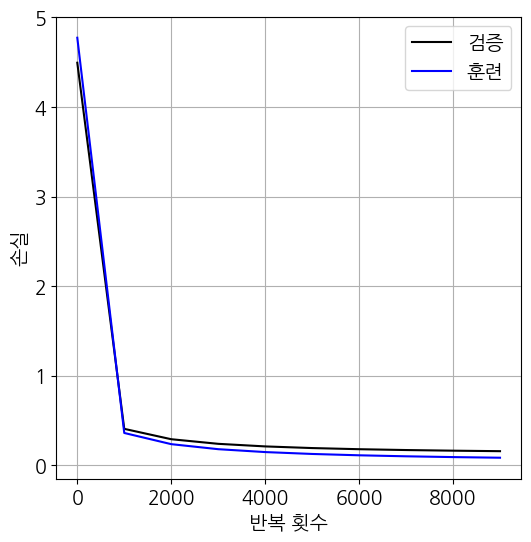

In [97]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,3], c='k', label='검증')
plt.plot(history[:,0], history[:,1], c='b', label='훈련')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.legend()
plt.show()

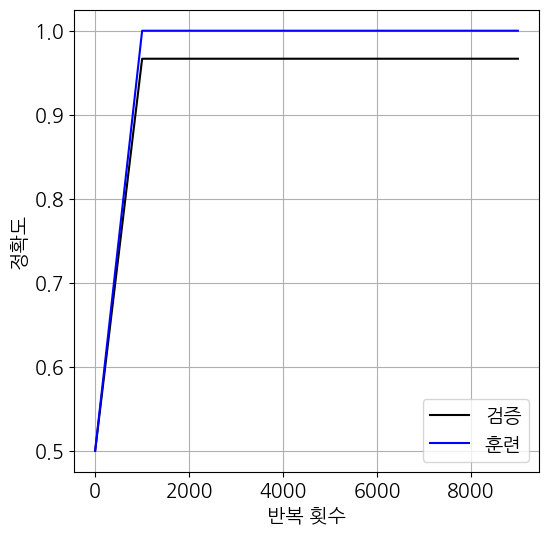

In [98]:
# 학습 곡선 출력(정확도)

plt.plot(history[:,0], history[:,4], c='k', label='검증')
plt.plot(history[:,0], history[:,2], c='b', label='훈련')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.legend()
plt.show()

In [99]:
# 검증 데이터 준비

x_t0 = x_test[y_test==0]
x_t1 = x_test[y_test==1]

In [100]:
# 파라미터 취득

bias = net.l1.bias.data.numpy()
weight = net.l1.weight.data.numpy()
print(f'BIAS = {bias}, WEIGHT = {weight}')

# 결정 경계를 그리기 위해 x1로부터 x2를 계산
def decision(x):
    return(-(bias + weight[0,0] * x)/ weight[0,1])

# 산포도의 x1의 최솟값과 최댓값
xl = np.array([x_test[:,0].min(), x_test[:,0].max()])
yl = decision(xl)

# 결과 확인
print(f'xl = {xl}  yl = {yl}')

BIAS = [0.3386], WEIGHT = [[ 2.97 -5.3 ]]
xl = [4.4 7. ]  yl = [2.5296 3.9866]


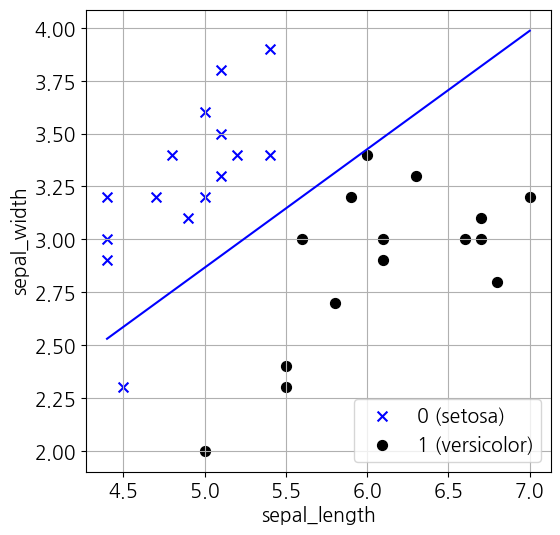

In [101]:
# 산포도 출력
plt.scatter(x_t0[:,0], x_t0[:,1], marker='x', c='b', s=50, label='0 (setosa)')
plt.scatter(x_t1[:,0], x_t1[:,1], marker='o', c='k', s=50, label='1 (versicolor)')

# 결정 경계 직선
plt.plot(xl, yl, c='b')
plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.legend()
plt.show()

<칼럼> BCELoss 함수와 BCEWithLogitsLoss 함수의 차이

[정리]

1. BCELOSS
- nn.Linear() >> nn.Sigmoid (2단계)
- 손실 임계값 y값은 [0,1], 0.5(threshold)
- 수치 안정성 : 낮음
2. BCEWithLogitsLOSS
- nn.Linear() 1단계 (nn.Sigmoid 내장)
- 손실 임계값 0 (threshold)
- 수치 안정성 : 높음

In [102]:
# 모델 정의
class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.l1 = nn.Linear(n_input, n_output)

        # 초깃값을 모두 1로 함
        self.l1.weight.data.fill_(1.0)
        self.l1.bias.data.fill_(1.0)

    def forward(self, x):
        x1 = self.l1(x)
        return x1

In [103]:
# 학습률
lr = 0.01

# 초기화
net = Net(n_input, n_output)

# 손실 함수
criterion = nn.BCEWithLogitsLoss()

# 최적화 함수
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epoch = 10000

# 기록용 리스트 초기화
history = np.zeros((0,5))

In [104]:
# 반복 계산 메인 루프
for epoch in range(num_epochs):
    # 훈련(학습)
    optimizer.zero_grad()      # 경삿값 초기화
    outputs = net(inputs)      # 예측 계산
    loss = criterion(outputs, labels1) # 손실 계산
    loss.backward()            # 경사 계산
    optimizer.step()           # 파라미터 수정

    train_loss = loss.item()   # 손실 저장 (스칼라 값 취득)
    # 확률값을 0.0 기준으로 0 또는 1로 변환
    predicted = torch.where(outputs < 0.0, 0, 1)
    # 정확도 계산
    train_acc = (predicted == labels1).sum() / len(y_train)

    # 예측
    # 여기서는 경사 계산과 파라미터 수정이 필요 없습니다.
    outputs_test = net(inputs_test) # 예측 계산
    loss_test = criterion(outputs_test, labels_test1) # 손실 계산
    val_loss = loss_test.item() # 손실 저장
    predicted_test = torch.where(outputs_test < 0.0, 0, 1) # 예측 라벨(1 또는 0) 계산
    val_acc = (predicted_test == labels_test1).sum() / len(y_test) # 정확도 계산

    # 1000번에 한 번씩 결과 출력
    if (epoch % 1000 == 0):
        print(f'Epoch [{epoch+1}/{num_epochs}], loss: {train_loss:.5f}, acc: {train_acc:.5f}, val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
        # 기록
        item = np.array([epoch, train_loss, train_acc, val_loss, val_acc])
        history = np.vstack((history, item))

Epoch [1/10000], loss: 4.77294, acc: 0.50000, val_loss: 4.49384, val_acc: 0.50000
Epoch [1001/10000], loss: 0.36160, acc: 1.00000, val_loss: 0.40759, val_acc: 0.96667
Epoch [2001/10000], loss: 0.23677, acc: 1.00000, val_loss: 0.29188, val_acc: 0.96667
Epoch [3001/10000], loss: 0.18060, acc: 1.00000, val_loss: 0.24044, val_acc: 0.96667
Epoch [4001/10000], loss: 0.14842, acc: 1.00000, val_loss: 0.21159, val_acc: 0.96667
Epoch [5001/10000], loss: 0.12737, acc: 1.00000, val_loss: 0.19317, val_acc: 0.96667
Epoch [6001/10000], loss: 0.11243, acc: 1.00000, val_loss: 0.18042, val_acc: 0.96667
Epoch [7001/10000], loss: 0.10121, acc: 1.00000, val_loss: 0.17109, val_acc: 0.96667
Epoch [8001/10000], loss: 0.09243, acc: 1.00000, val_loss: 0.16398, val_acc: 0.96667
Epoch [9001/10000], loss: 0.08535, acc: 1.00000, val_loss: 0.15839, val_acc: 0.96667


In [105]:
# 손실과 정확도 확인

print(f'초기상태 : 손실 : {history[0,3]:.5f} 정확도 : {history[0,4]:.5f}')
print(f'최종상태 : 손실 : {history[-1,3]:.5f} 정확도 : {history[-1,4]:.5f}')

초기상태 : 손실 : 4.49384 정확도 : 0.50000
최종상태 : 손실 : 0.15839 정확도 : 0.96667


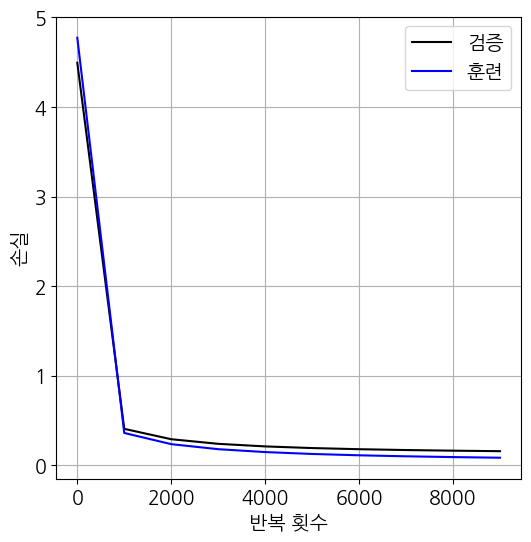

In [106]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,3], c='k', label='검증')
plt.plot(history[:,0], history[:,1], c='b', label='훈련')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.legend()
plt.show()

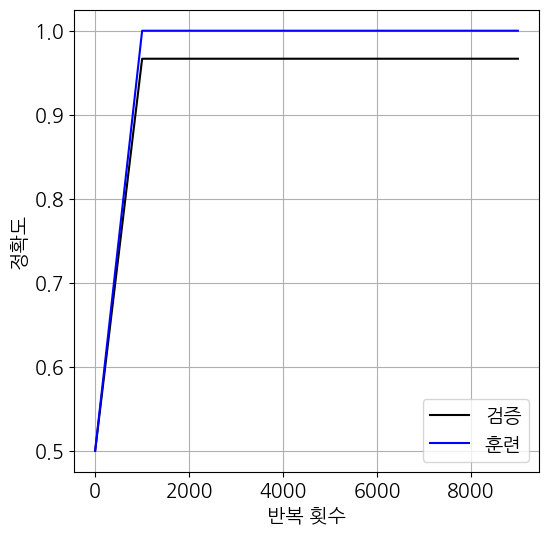

In [107]:
# 학습 곡선 출력(정확도)

plt.plot(history[:,0], history[:,4], c='k', label='검증')
plt.plot(history[:,0], history[:,2], c='b', label='훈련')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.legend()
plt.show()

In [107]:
# eos